# Build cache tiền xử lý — W2 ngày 3

> **Research Use Only (RUO)** — chưa kiểm định lâm sàng, không dùng chẩn đoán.

Đưa 498 bệnh nhân × 8 pha về **một lưới mm chung** quanh tổn thương, rồi cache lại
để mọi lần train sau chỉ việc mount.

**Thứ tự bắt buộc:**
1. Bootstrap (clone lại code mới nhất — kiểm dòng `repo commit`)
2. **Phán quyết thứ tự trục** → điền vào `configs/preprocess.yaml`
3. Chạy thử vài ca, xem ảnh xác nhận tổn thương nằm giữa patch
4. Build toàn bộ
5. Kiểm tra cache
6. Đẩy thành Kaggle Dataset

⚠️ Bước 2 là **cổng chặn**: `build_cache` sẽ từ chối chạy nếu `axis_order` để trống.

## 0. Bootstrap

Luôn xoá + clone lại. Dòng `repo commit` là bằng chứng đang chạy đúng bản code nào —
nếu nó không khớp commit mới nhất trên GitHub thì mọi thứ bên dưới đều vô nghĩa.

In [1]:
import os
import subprocess
import sys
from pathlib import Path

REPO_URL = "https://github.com/hdtruong802/liver-mri-3d-classifier.git"
ON_KAGGLE = Path("/kaggle/input").exists()

if ON_KAGGLE:
    REPO = Path("/kaggle/working/repo")
    subprocess.run(["rm", "-rf", str(REPO)], check=False)
    subprocess.run(["git", "clone", "-q", REPO_URL, str(REPO)], check=True)
    sys.path.insert(0, str(REPO))
    os.environ["LLDMMRI_CACHE_DIR"] = "/kaggle/working/cache"
else:
    REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
    sys.path.insert(0, str(REPO))

os.environ.pop("LLDMMRI_DATA_ROOT", None)  # env sót từ lần chạy trước sẽ đè config mới

print("repo commit:", subprocess.run(
    ["git", "-C", str(REPO), "log", "-1", "--format=%h %s"],
    capture_output=True, text=True,
).stdout.strip())

if ON_KAGGLE:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "SimpleITK", "nibabel"], check=False)

from src.data.annotation import Annotation  # noqa: E402
from src.data.images import scan_image_index  # noqa: E402
from src.utils.io import load_yaml, resolve_data_root  # noqa: E402
from src.utils.seed import set_seed  # noqa: E402

DATA_CFG = load_yaml(REPO / "configs" / "data.yaml")
PRE_CFG = load_yaml(REPO / "configs" / "preprocess.yaml")
set_seed(DATA_CFG["seed"])

DATA_ROOT = resolve_data_root(DATA_CFG)
PHASES = DATA_CFG["phases"]
ann = Annotation(DATA_ROOT / DATA_CFG["annotation_rel"])
index = scan_image_index(DATA_ROOT / DATA_CFG["images_rel"], DATA_CFG["image_suffixes"])

print("data root :", DATA_ROOT)
print("bệnh nhân :", len(ann), "| file ảnh:", len(index))

repo commit: 8f23196 fix(geometry): đo độ tán chỉ trong mặt phẳng — trục Z là nhiễu hô hấp
data root : /kaggle/input/datasets/marcohoang/lldmmridataset
bệnh nhân : 498 | file ảnh: 3984


## 1. Phán quyết thứ tự trục ⚠️ CỔNG CHẶN

`bbox.x` ứng với trục 0 hay trục 1 của mảng? Crop sai trục ⇒ lệch 90° ⇒ mọi kết quả
sau đều vô nghĩa.

Kiểm biên không giải được (mọi ảnh đều vuông: 0/3984 ảnh không vuông). Cách dùng ở đây:
annotation cho bbox **riêng cho từng pha**; cùng một tổn thương vật lý nên khi đổi tâm
bbox sang mm, 8 pha phải **hội tụ về một điểm**. Cách hiểu sai làm chúng tán ra.

Chỉ tính phiếu từ ca thật sự phân biệt được (chênh ≥5mm giữa hai cách hiểu) — trên dữ
liệu này khoảng 200/498 ca có tín hiệu quá yếu, gộp vào chỉ thêm nhiễu.

In [2]:
from src.preprocess.geometry import resolve_axis_order

verdict = resolve_axis_order(ann.patient_ids(), ann, index, PHASES)
print(verdict.summary())
print()
if verdict.verdict == "inconclusive":
    print("!! KHÔNG kết luận được -> chạy tiếp mục 2 (overlay) trước khi build cache")
else:
    print(f'>> Điền vào configs/preprocess.yaml:  axis_order: "{verdict.verdict}"')

AXIS ORDER (toạ độ thế giới): xy
  498 bệnh nhân so được · 180 ca có sức phân biệt (chênh ≥ 5mm)
  xy: 166 phiếu (92%) · độ tán TRONG MẶT PHẲNG, trung vị = 12.4 mm
  yx: 14 phiếu (8%) · độ tán TRONG MẶT PHẲNG, trung vị = 17.8 mm
  (độ tán nhỏ = các pha chỉ về cùng một điểm ⇒ cách hiểu đúng)
  (trục Z bị loại khỏi phép đo: hoán vị trục không đụng Z, và Z bị
   chuyển động hô hấp chi phối ~23mm — nhiễu chung cho cả hai cách hiểu)

>> Điền vào configs/preprocess.yaml:  axis_order: "xy"


## 2. Xác nhận bằng mắt (bắt buộc chạy, kể cả khi mục 1 đã kết luận)

Vẽ bbox lên lát cắt giữa tổn thương theo **cả hai** cách hiểu. Cách đúng phải trùng
vùng tổn thương. Đây là kiểm chứng độc lập với mục 1 — nếu hai bên mâu thuẫn thì
**dừng lại**, đừng chọn bừa.

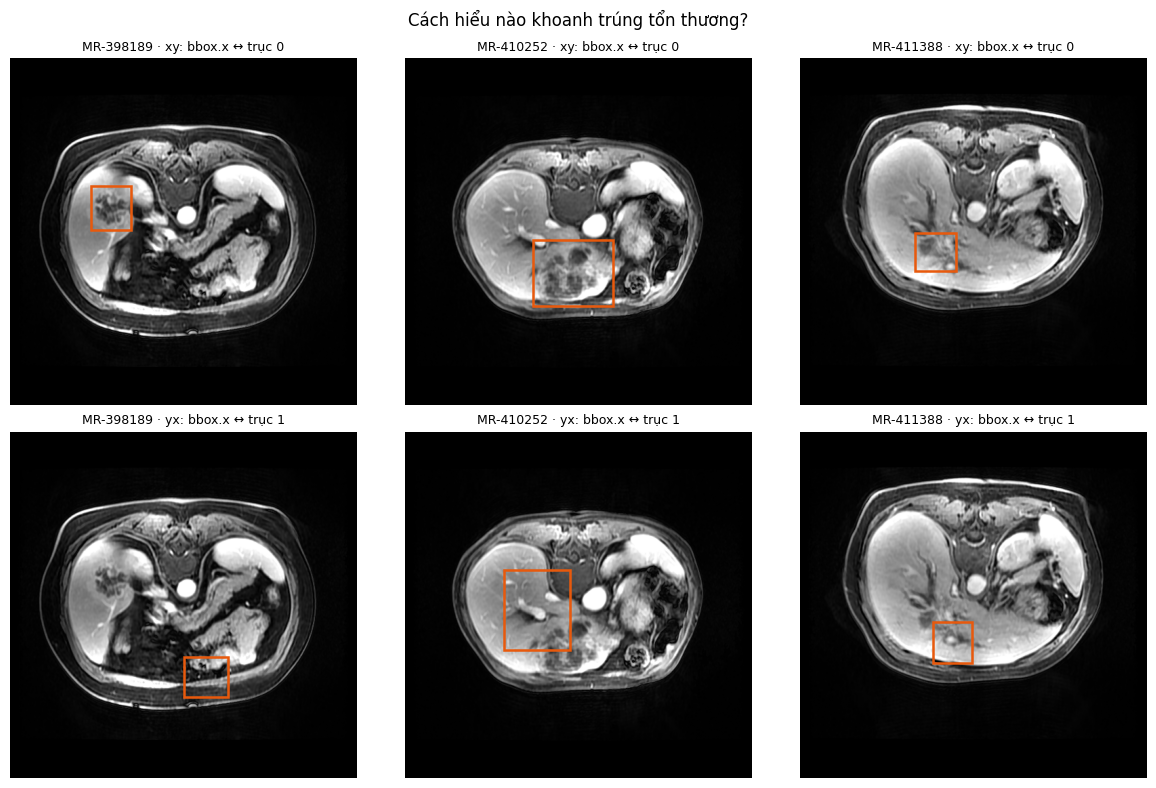

In [3]:
import matplotlib.pyplot as plt
import nibabel as nib
import numpy as np
from matplotlib import patches

from src.utils.ids import normalize_pid

ref_phase = PRE_CFG["reference_phase"]
ref_token = next(p["file"] for p in PHASES if p["name"] == ref_phase)

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for col, pid in enumerate(ann.patient_ids()[:3]):
    box = ann.bbox3d(pid, ref_phase)
    mid = (box.z_min + box.z_max) // 2
    path = index[(normalize_pid(pid), ref_token)]
    sl = np.asarray(nib.load(str(path)).dataobj[:, :, mid])

    for row, (order, rect) in enumerate([
        ("xy: bbox.x ↔ trục 0", (box.x_min, box.y_min, box.x_max - box.x_min, box.y_max - box.y_min)),
        ("yx: bbox.x ↔ trục 1", (box.y_min, box.x_min, box.y_max - box.y_min, box.x_max - box.x_min)),
    ]):
        ax = axes[row, col]
        ax.imshow(sl.T, cmap="gray", origin="lower")
        ax.add_patch(patches.Rectangle(rect[:2], rect[2], rect[3],
                                       linewidth=1.8, edgecolor="#e8590c", facecolor="none"))
        ax.set_title(f"{pid} · {order}", fontsize=9)
        ax.axis("off")
fig.suptitle("Cách hiểu nào khoanh trúng tổn thương?", fontsize=12)
plt.tight_layout()
plt.show()

## 3. Chạy thử 3 ca — kiểm tổn thương có nằm giữa patch không

Trước khi tốn 30–60 phút cho 498 ca, thử vài ca đã. Tổn thương phải nằm **giữa** patch
ở **mọi** pha — đó là bằng chứng lưới đích và phép lấy mẫu đúng.

⚠️ Nhớ điền `axis_order` vào `configs/preprocess.yaml` và **push lên GitHub** trước,
vì cell bootstrap clone lại từ đó. Hoặc sửa nhanh `PRE_CFG` bên dưới để thử.

In [4]:
# Sửa nhanh để thử (bản chính thức phải nằm trong configs/preprocess.yaml đã push)
PRE_CFG["axis_order"] = PRE_CFG.get("axis_order") or verdict.verdict
print("axis_order dùng:", PRE_CFG["axis_order"])

from src.preprocess.build_cache import process_patient

sample_ids = ann.patient_ids()[:3]
for pid in sample_ids:
    vol = process_patient(pid, ann, index, PHASES, PRE_CFG)
    print(f"{pid}: shape={vol.shape} finite={np.isfinite(vol).all()} "
          f"mean={vol.mean():.3f} std={vol.std():.3f}")

axis_order dùng: xy
MR-398189: shape=(8, 96, 96, 48) finite=True mean=1.013 std=1.020
MR-410252: shape=(8, 96, 96, 48) finite=True mean=1.071 std=1.217
MR-411388: shape=(8, 96, 96, 48) finite=True mean=0.987 std=1.026


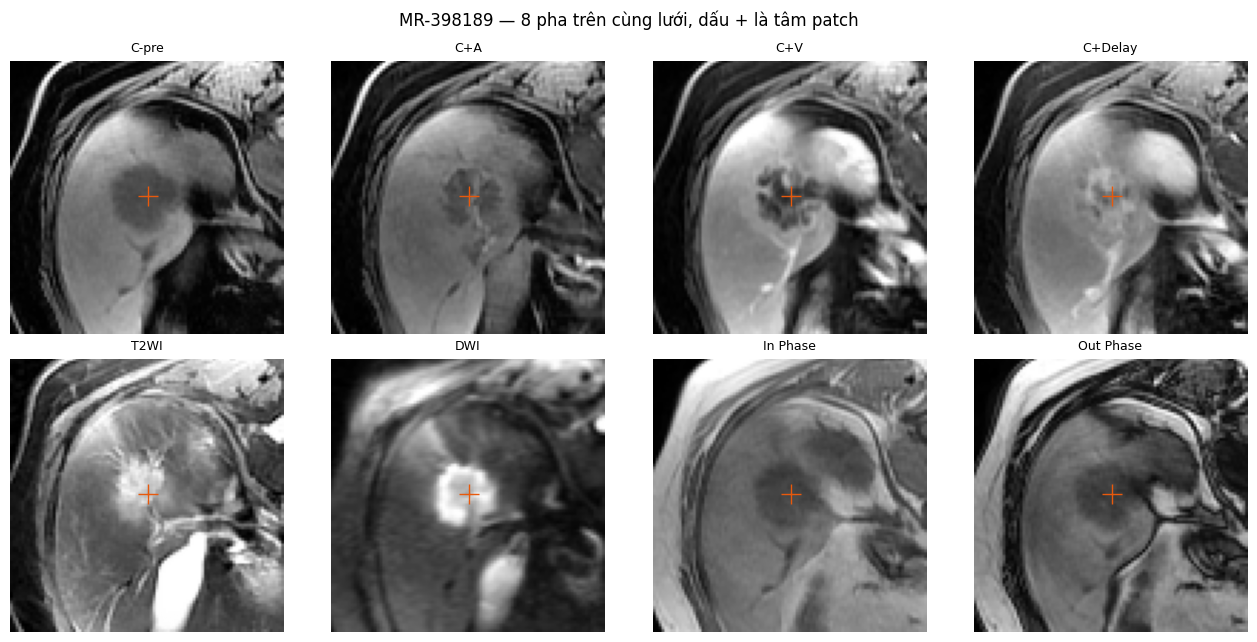

In [5]:
# Nhìn 8 pha của 1 ca: tổn thương phải ở giữa mọi ô
vol = process_patient(sample_ids[0], ann, index, PHASES, PRE_CFG)
mid_z = vol.shape[3] // 2

fig, axes = plt.subplots(2, 4, figsize=(13, 6.5))
for i, (ax, phase) in enumerate(zip(axes.ravel(), PHASES, strict=False)):
    ax.imshow(vol[i, :, :, mid_z].T, cmap="gray", origin="lower")
    ax.plot(vol.shape[1] / 2, vol.shape[2] / 2, "+", color="#e8590c", markersize=14)
    ax.set_title(phase["name"], fontsize=9)
    ax.axis("off")
fig.suptitle(f"{sample_ids[0]} — 8 pha trên cùng lưới, dấu + là tâm patch", fontsize=12)
plt.tight_layout()
plt.show()

## 4. Build toàn bộ 498 ca

Ước lượng 30–60 phút (đọc ~80GB). **Resume được**: ca nào đã có file thì bỏ qua, nên
nếu Kaggle ngắt session giữa chừng thì chạy lại cell này là tiếp tục.

In [6]:
from src.preprocess.build_cache import build_cache

cache_dir = build_cache(REPO / "configs" / "preprocess.yaml")
print("cache:", cache_dir)

2026-07-27 05:22:30,953 INFO src.preprocess.build_cache | 25/498 | xong 25, bỏ qua 0, lỗi 0 | 1.2 phút
2026-07-27 05:23:42,676 INFO src.preprocess.build_cache | 50/498 | xong 50, bỏ qua 0, lỗi 0 | 2.4 phút
2026-07-27 05:25:01,253 INFO src.preprocess.build_cache | 75/498 | xong 75, bỏ qua 0, lỗi 0 | 3.7 phút
2026-07-27 05:26:16,301 INFO src.preprocess.build_cache | 100/498 | xong 100, bỏ qua 0, lỗi 0 | 5.0 phút
2026-07-27 05:27:44,036 INFO src.preprocess.build_cache | 125/498 | xong 125, bỏ qua 0, lỗi 0 | 6.4 phút
2026-07-27 05:28:53,438 INFO src.preprocess.build_cache | 150/498 | xong 150, bỏ qua 0, lỗi 0 | 7.6 phút
2026-07-27 05:29:59,701 INFO src.preprocess.build_cache | 175/498 | xong 175, bỏ qua 0, lỗi 0 | 8.7 phút
2026-07-27 05:31:09,210 INFO src.preprocess.build_cache | 200/498 | xong 200, bỏ qua 0, lỗi 0 | 9.8 phút
2026-07-27 05:32:17,857 INFO src.preprocess.build_cache | 225/498 | xong 225, bỏ qua 0, lỗi 0 | 11.0 phút
2026-07-27 05:33:27,479 INFO src.preprocess.build_cache | 25

cache: /kaggle/working/cache


## 5. Kiểm tra cache

Tiêu chí nghiệm thu: đủ 498 file, shape đúng, không NaN/Inf, mean≈0 std≈1 theo từng pha.

In [7]:
import json

files = sorted(cache_dir.glob("*.npz"))
print(f"số file: {len(files)} (cần 498)")
print("meta:", json.loads((cache_dir / "cache_meta.json").read_text(encoding="utf-8")))

bad = []
for path in files[:20]:
    with np.load(path) as d:
        img = d["image"].astype(np.float32)
        if not np.isfinite(img).all() or img.shape != tuple([8] + PRE_CFG["target_size"]):
            bad.append(path.name)
print("file lỗi trong 20 ca đầu:", bad or "không có")

with np.load(files[0]) as d:
    img = d["image"].astype(np.float32)
    print(f"\n{files[0].name}: shape={img.shape} label={int(d['label'])}")
    for i, phase in enumerate(PHASES):
        print(f"  {phase['name']:<11} mean={img[i].mean():+.3f} std={img[i].std():.3f}")

số file: 498 (cần 498)
meta: {'axis_order': 'xy', 'reference_phase': 'C+V', 'target_spacing': [1.5, 1.5, 3.0], 'target_size': [96, 96, 48], 'interpolator': 'linear', 'normalize': {'clip_percentile': [0.5, 99.5], 'scope': 'volume'}, 'n4': False, 'output_dtype': 'float16', 'phases': ['C-pre', 'C+A', 'C+V', 'C+Delay', 'T2WI', 'DWI', 'In Phase', 'Out Phase'], 'git_commit': 'unknown'}
file lỗi trong 20 ca đầu: không có

MR-391135.npz: shape=(8, 96, 96, 48) label=1
  C-pre       mean=+0.431 std=1.048
  C+A         mean=+0.440 std=1.050
  C+V         mean=+0.545 std=1.213
  C+Delay     mean=+0.515 std=1.141
  T2WI        mean=+0.480 std=1.109
  DWI         mean=+0.324 std=0.869
  In Phase    mean=+0.304 std=0.879
  Out Phase   mean=+0.252 std=0.880


In [8]:
# Smoke test "sẵn sàng train": dựng DataLoader từ fold 1
from torch.utils.data import DataLoader

from src.data.dataset import build_fold_datasets

train_ds, val_ds = build_fold_datasets(cache_dir, fold_index=1, splits_dir=REPO / "splits")
print(f"train={len(train_ds)} val={len(val_ds)} (tổng phải = 394)")

batch = next(iter(DataLoader(train_ds, batch_size=4, shuffle=True)))
print("batch image:", tuple(batch["image"].shape), batch["image"].dtype)
print("batch label:", batch["label"].tolist())

train=312 val=82 (tổng phải = 394)
batch image: (4, 8, 96, 96, 48) torch.float32
batch label: [4, 1, 6, 2]


## 6. Đẩy cache thành Kaggle Dataset

⚠️ **Để Private** — LLD-MMRI dùng license CC BY-NC-ND, không được phát tán bản phái sinh.

Sau khi đẩy xong, ghi **slug + version** vào comment đầu `configs/preprocess.yaml` và
vào WORKLOG — không có dòng đó thì vài tuần sau không ai biết checkpoint được train
bằng cache nào.

In [9]:
import json

SLUG = "lldmmri-cache-v1"
USER = "marcohoang"

(cache_dir / "dataset-metadata.json").write_text(json.dumps({
    "title": "LLD-MMRI preprocessed cache (96x96x48 @1.5x1.5x3.0mm)",
    "id": f"{USER}/{SLUG}",
    "licenses": [{"name": "other"}],
}), encoding="utf-8")

print("Chạy lệnh sau (lần đầu dùng create, các lần sau dùng version):")
print(f"  !kaggle datasets create -p {cache_dir} --dir-mode zip")
print(f"  !kaggle datasets version -p {cache_dir} -m 'cap nhat' --dir-mode zip")

Chạy lệnh sau (lần đầu dùng create, các lần sau dùng version):
  !kaggle datasets create -p /kaggle/working/cache --dir-mode zip
  !kaggle datasets version -p /kaggle/working/cache -m 'cap nhat' --dir-mode zip
